In [8]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [9]:
import os

for root, dirs, files in os.walk('/content/data'):
    for file in files:
        print(os.path.join(root, file))

/content/data/Advertising.csv


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data = pd.read_csv('/content/data/Advertising.csv')

In [12]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [14]:
data.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [15]:
print(data.columns)

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [16]:
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (160, 3)
Testing Shape: (40, 3)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [19]:
predictions = model.predict(X_test)

print(predictions[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("Mean Squared Error:", mean_squared_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

Mean Absolute Error: 1.4607567168117603
Mean Squared Error: 3.1740973539761033
R2 Score: 0.899438024100912


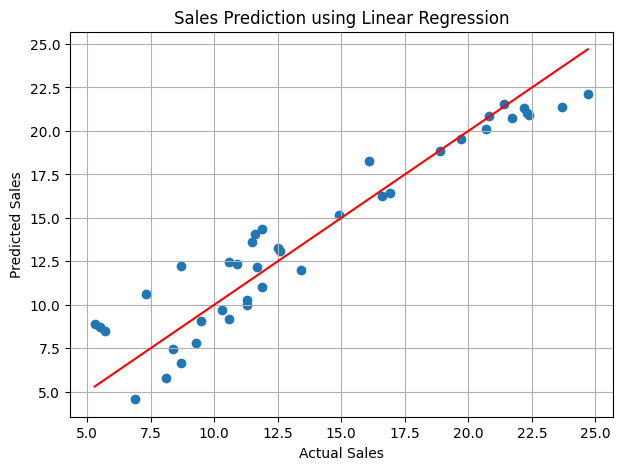

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.title("Sales Prediction using Linear Regression")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

In [24]:
new_data = pd.DataFrame({
    'TV': [230],
    'Radio': [37],
    'Newspaper': [69]
})

prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 20.45759025215365
